# Notebook 04 — Visualizaciones
Genera 4 gráficas desde `data/resultados_reglas.csv` y `data/resultados_zscore.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

os.makedirs('../data', exist_ok=True)

df_r = pd.read_csv('../data/resultados_reglas.csv')
df_z = pd.read_csv('../data/resultados_zscore.csv')

print('resultados_reglas:', df_r.shape)
print('resultados_zscore:', df_z.shape)

resultados_reglas: (50, 18)
resultados_zscore: (50, 21)


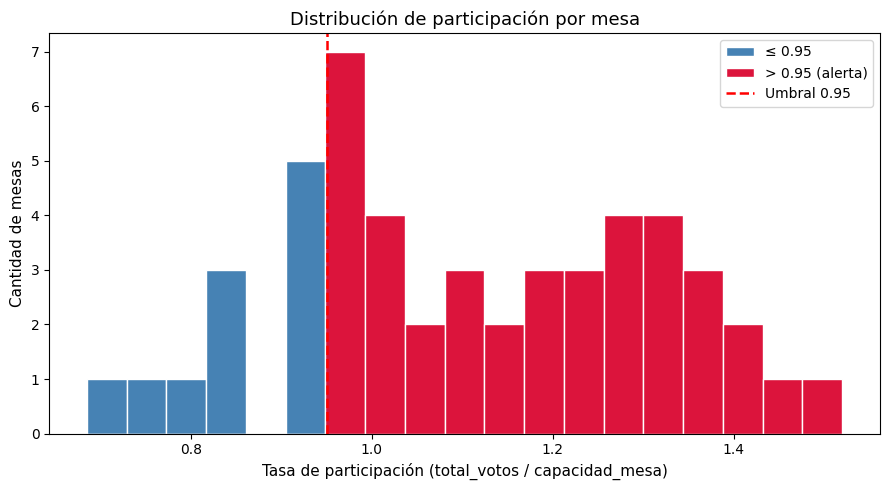

Guardado: ../data/g1_participacion.png


In [2]:
# --- Gráfica 1: Histograma de tasa de participación ---
df_r['tasa'] = df_r['total_votos'] / df_r['capacidad_mesa']
UMBRAL = 0.95

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(df_r['tasa'].min() - 0.02, df_r['tasa'].max() + 0.02, 20)

bajo  = df_r[df_r['tasa'] <= UMBRAL]['tasa']
alto  = df_r[df_r['tasa'] > UMBRAL]['tasa']
ax.hist(bajo, bins=bins, color='steelblue', edgecolor='white', label='≤ 0.95')
ax.hist(alto, bins=bins, color='crimson',   edgecolor='white', label='> 0.95 (alerta)')
ax.axvline(UMBRAL, color='red', linestyle='--', linewidth=1.8, label='Umbral 0.95')
ax.set_xlabel('Tasa de participación (total_votos / capacidad_mesa)', fontsize=11)
ax.set_ylabel('Cantidad de mesas', fontsize=11)
ax.set_title('Distribución de participación por mesa', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../data/g1_participacion.png', dpi=120)
plt.show()
print('Guardado: ../data/g1_participacion.png')

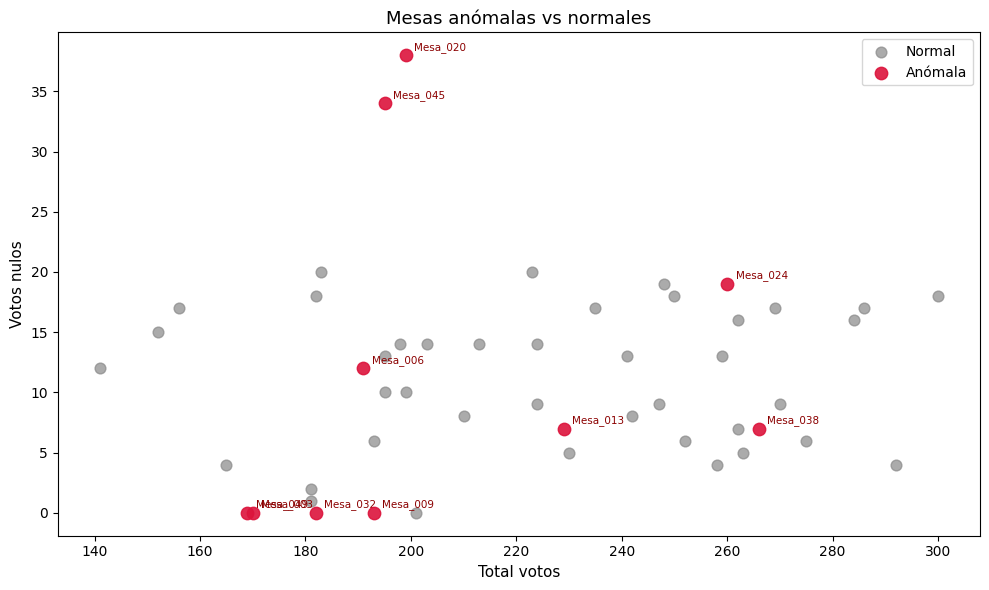

Guardado: ../data/g2_scatter_anomalias.png


In [3]:
# --- Gráfica 2: Scatter total_votos vs votos_nulos ---
fig, ax = plt.subplots(figsize=(10, 6))

normales  = df_r[df_r['tiene_anomalia'] == False]
anomalas  = df_r[df_r['tiene_anomalia'] == True]

ax.scatter(normales['total_votos'], normales['votos_nulos'],
           color='#888888', alpha=0.7, s=60, label='Normal')
ax.scatter(anomalas['total_votos'], anomalas['votos_nulos'],
           color='crimson', alpha=0.9, s=80, zorder=5, label='Anómala')

for _, row in anomalas.iterrows():
    ax.annotate(row['mesa_id'],
                xy=(row['total_votos'], row['votos_nulos']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=7.5, color='darkred')

ax.set_xlabel('Total votos', fontsize=11)
ax.set_ylabel('Votos nulos', fontsize=11)
ax.set_title('Mesas anómalas vs normales', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../data/g2_scatter_anomalias.png', dpi=120)
plt.show()
print('Guardado: ../data/g2_scatter_anomalias.png')

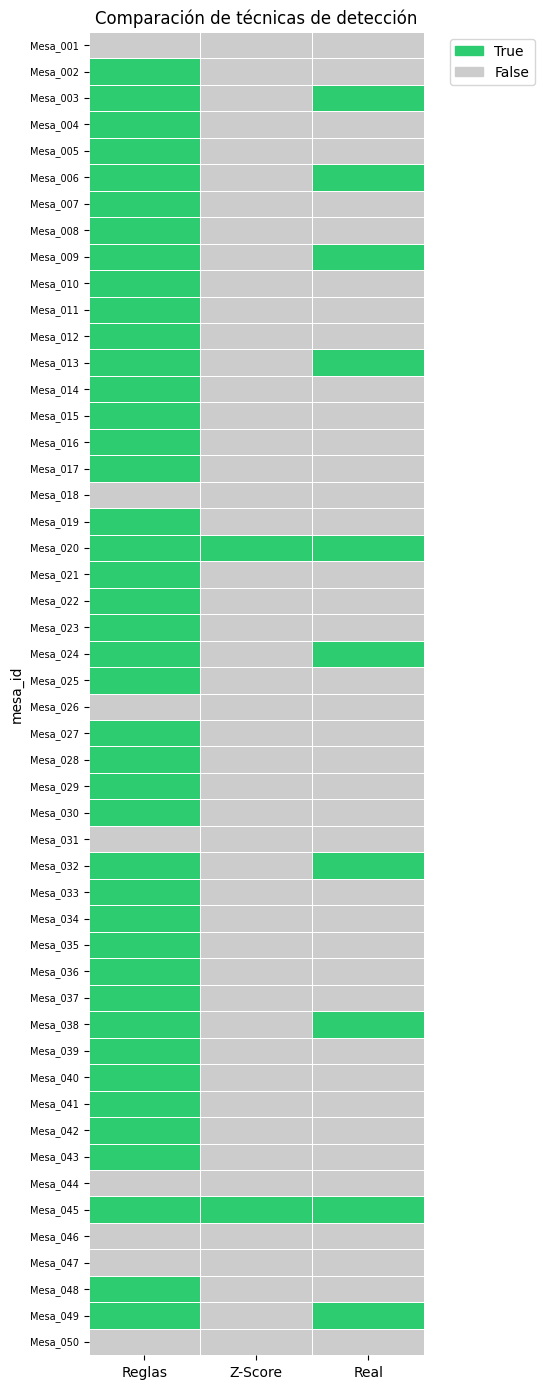

Guardado: ../data/g3_comparacion_tecnicas.png


In [4]:
# --- Gráfica 3: Heatmap comparación de técnicas ---
merged = df_r[['mesa_id','sospechosa_reglas','tiene_anomalia']].copy()
merged = merged.merge(df_z[['mesa_id','sospechosa_zscore']], on='mesa_id')

hm_data = merged[['sospechosa_reglas','sospechosa_zscore','tiene_anomalia']].astype(int)
hm_data.index = merged['mesa_id']

fig, ax = plt.subplots(figsize=(6, 14))
sns.heatmap(hm_data, ax=ax,
            cmap=['#cccccc','#2ecc71'],  # gris=False, verde=True
            linewidths=0.5, linecolor='white',
            cbar=False,
            xticklabels=['Reglas','Z-Score','Real'],
            yticklabels=hm_data.index)
ax.set_title('Comparación de técnicas de detección', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=7)

parches = [
    mpatches.Patch(color='#2ecc71', label='True'),
    mpatches.Patch(color='#cccccc', label='False'),
]
ax.legend(handles=parches, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.savefig('../data/g3_comparacion_tecnicas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: ../data/g3_comparacion_tecnicas.png')

C:\Users\river\AppData\Local\Temp\ipykernel_9880\1951672426.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxplot, labels=orden, patch_artist=True, notch=False)


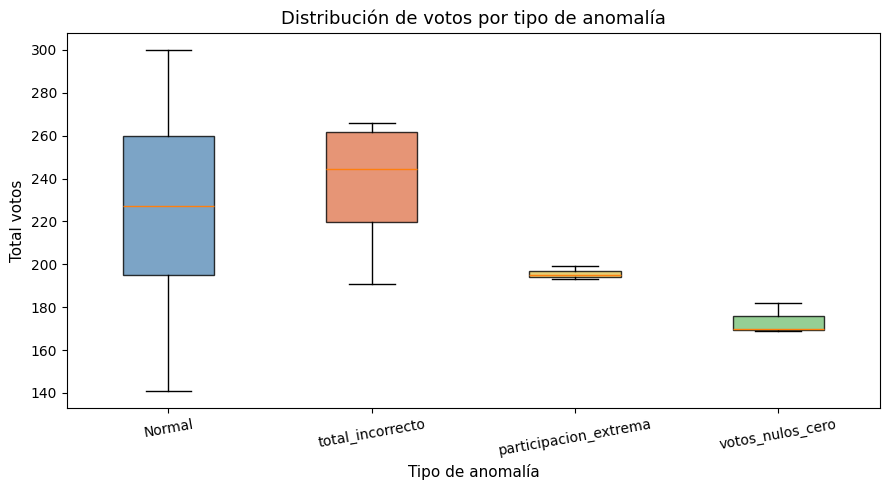

Guardado: ../data/g4_boxplot.png


In [5]:
# --- Gráfica 4: Boxplot total_votos por tipo_anomalia ---
df_box = df_r.copy()
df_box['tipo_anomalia'] = df_box['tipo_anomalia'].fillna('Normal')

orden = ['Normal', 'total_incorrecto', 'participacion_extrema', 'votos_nulos_cero']

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['#5b8db8', '#e07b54', '#e0c454', '#7bc47b']

data_boxplot = [df_box[df_box['tipo_anomalia'] == t]['total_votos'].values for t in orden]
bp = ax.boxplot(data_boxplot, labels=orden, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xlabel('Tipo de anomalía', fontsize=11)
ax.set_ylabel('Total votos', fontsize=11)
ax.set_title('Distribución de votos por tipo de anomalía', fontsize=13)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('../data/g4_boxplot.png', dpi=120)
plt.show()
print('Guardado: ../data/g4_boxplot.png')

In [6]:
# Verificar que los 4 PNG existen
pngs = ['g1_participacion.png','g2_scatter_anomalias.png',
        'g3_comparacion_tecnicas.png','g4_boxplot.png']
for f in pngs:
    ruta = f'../data/{f}'
    existe = os.path.exists(ruta)
    print(f'{"OK" if existe else "FALTA"}: {ruta}')

OK: ../data/g1_participacion.png
OK: ../data/g2_scatter_anomalias.png
OK: ../data/g3_comparacion_tecnicas.png
OK: ../data/g4_boxplot.png
